In [ ]:
# 1. Gerekli kütüphanelerin kurulumu (Colab'da yüklü olmayanlar)
!pip install rdkit chembl_webresource_client tqdm joblib

# 2. Google Drive'ı bağlama (Dosyaların kalıcı olması için)
from google.colab import drive
import os

drive.mount('/content/drive')

# 3. Proje klasörü oluşturma
# Drive içinde "Bitirme_Projesi" adında bir klasör oluşturur ve oraya geçer.
project_path = '/content/drive/MyDrive/Bitirme_Projesi'
if not os.path.exists(project_path):
    os.makedirs(project_path)

os.chdir(project_path)

print(f"\n✅ Ortam Hazır!")
print(f"📁 Çalışma dizini: {os.getcwd()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 5.5 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Ortam Hazır!
📁 Çalışma dizini: /content/drive/MyDrive/Bitirme_Projesi


VERİ TOPLAMA

In [ ]:
# --- AKADEMİK SEVİYE VERİ TOPLAMA VE KALİTE KONTROLÜ ---
import pandas as pd
from chembl_webresource_client.new_client import new_client
from tqdm import tqdm
import time

def academic_data_collector():
    print("🌐 ChEMBL Veri Tabanı Akademik Tarama Başlatıldı...")

    target_api = new_client.target
    activity_api = new_client.activity

    # 1. En çok IC50 verisine sahip insan (Homo sapiens) hedeflerini bulalım
    print("🎯 En zengin veri kaynakları (Protein Targets) belirleniyor...")
    human_targets = target_api.filter(target_type='SINGLE PROTEIN').filter(organism='Homo sapiens')

    # Veri yoğunluğu olan ilk 50 hedefi listeleyelim (Makale için geniş spektrum)
    target_list = pd.DataFrame.from_dict(human_targets)
    # Target listesini çekmek vakit alabilir, en yüksek aktivite sayısına göre sıralama simülasyonu:
    # Gerçek uygulamada popüler hedefleri manuel seçmek veya ilk X tanesini taramak daha garantidir.
    target_ids = target_list.target_chembl_id.tolist()[:30]

    all_data = []

    for t_id in tqdm(target_ids, desc="Protein Hedefleri İşleniyor"):
        try:
            # Filtreler: IC50, Birim: nM, İlişki: '=', Organizma: İnsan
            res = activity_api.filter(target_chembl_id=t_id) \
                              .filter(standard_type="IC50") \
                              .filter(standard_units="nM") \
                              .filter(relation="=")

            for r in res:
                smiles = r.get("canonical_smiles")
                value = r.get("standard_value")
                if smiles and value:
                    all_data.append({
                        "target_id": t_id,
                        "smiles": smiles,
                        "ic50": float(value)
                    })
                # Bellek yönetimi: Tek hedefte aşırı veri varsa sınırlayabiliriz (Opsiyonel)
                if len(all_data) > 20000: break

            time.sleep(0.2)
        except Exception as e:
            continue

    df = pd.DataFrame(all_data)

    # 2. Moleküler Temizlik ve Tekilleştirme
    initial_count = len(df)
    df = df.drop_duplicates(subset=['smiles'])

    # Makale kriteri: Aykırı değerleri (Outliers) temizleme
    # Çok yüksek veya çok düşük (ölçüm hatası olabilecek) IC50 değerlerini filtrele
    df = df[(df['ic50'] > 0.01) & (df['ic50'] < 1000000)]

    output_file = "academic_raw_data.csv"
    df.to_csv(output_file, index=False)

    print(f"\n✅ Veri Toplama Tamamlandı!")
    print(f"📦 Ham Veri Sayısı: {initial_count}")
    print(f"💎 Benzersiz ve Filtrelenmiş Molekül Sayısı: {len(df)}")
    print(f"📁 Dosya: {output_file}")

academic_data_collector()

🌐 ChEMBL Veri Tabanı Akademik Tarama Başlatıldı...
🎯 En zengin veri kaynakları (Protein Targets) belirleniyor...


Protein Hedefleri İşleniyor: 100%|██████████| 30/30 [13:11<00:00, 26.38s/it]



✅ Veri Toplama Tamamlandı!
📦 Ham Veri Sayısı: 20023
💎 Benzersiz ve Filtrelenmiş Molekül Sayısı: 12680
📁 Dosya: academic_raw_data.csv


Standardizasyon ve Özellik Çıkarımı

In [ ]:
# --- ADIM 3: AKADEMİK ÖZELLİK ÇIKARIMI VE MOLEKÜLER KÜRASYON ---
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, SaltRemover
from rdkit.ML.Descriptors import MoleculeDescriptors
from tqdm import tqdm
import numpy as np

def academic_feature_extraction():
    print("📂 'academic_raw_data.csv' yükleniyor...")
    df = pd.read_csv("academic_raw_data.csv")

    # Tuz temizleyici ve hesaplayıcıyı hazırla
    remover = SaltRemover.SaltRemover()
    descriptor_names = [desc_name for desc_name, _ in Descriptors._descList]
    calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

    valid_data = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Moleküller Küratize Ediliyor"):
        try:
            mol = Chem.MolFromSmiles(row['smiles'])
            if mol:
                # 1. Kimyasal Temizlik (Sanitization)
                Chem.SanitizeMol(mol)
                # 2. Tuzları Temizle
                mol = remover.StripMol(mol)

                # 3. Descriptorları Hesapla
                desc_values = list(calculator.CalcDescriptors(mol))

                # Bilgileri birleştir
                record = {
                    "smiles": row['smiles'],
                    "target_id": row['target_id'],
                    "ic50": row['ic50']
                }
                # Descriptorları sözlüğe ekle
                for i, name in enumerate(descriptor_names):
                    record[name] = desc_values[i]

                valid_data.append(record)
        except:
            continue

    # DataFrame oluştur
    final_df = pd.DataFrame(valid_data)

    # --- İSTATİSTİKSEL FİLTRELEME ---
    print("\n🧹 Aykırı değerler ve hatalı veriler temizleniyor...")
    # Sayısal olmayanları temizle ve sonsuz değerleri düzelt
    final_df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Sadece sayısal descriptor sütunlarını seç
    numeric_cols = descriptor_names
    # Eksik verisi çok olan sütunları veya satırları temizle
    final_df = final_df.dropna(subset=numeric_cols, how='any')

    # IC50 değerini pIC50'ye çevirme (Makale standardı: -log10(Molar))
    # ChEMBL verisi nM (10^-9) olduğu için: pIC50 = 9 - log10(IC50_nM)
    final_df['pIC50'] = 9 - np.log10(final_df['ic50'].astype(float))

    output_file = "academic_processed_descriptors.csv"
    final_df.to_csv(output_file, index=False)

    print(f"\n✅ Kürasyon Tamamlandı!")
    print(f"💎 Nihai Veri Seti: {len(final_df)} molekül x {final_df.shape[1]} sütun")
    print(f"📝 Not: IC50 değerleri akademik standart olan 'pIC50' ölçeğine dönüştürüldü.")

academic_feature_extraction()

📂 'academic_raw_data.csv' yükleniyor...


Moleküller Küratize Ediliyor: 100%|██████████| 12680/12680 [04:19<00:00, 48.84it/s]



🧹 Aykırı değerler ve hatalı veriler temizleniyor...

✅ Kürasyon Tamamlandı!
💎 Nihai Veri Seti: 12671 molekül x 221 sütun
📝 Not: IC50 değerleri akademik standart olan 'pIC50' ölçeğine dönüştürüldü.


veri bölme ve normalizasyon

In [ ]:
# --- ADIM 4: AKADEMİK NORMALİZASYON VE VERİ BÖLME ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

def academic_preprocessing():
    print("📂 'academic_processed_descriptors.csv' yükleniyor...")
    df = pd.read_csv("academic_processed_descriptors.csv")

    # 1. Descriptor'ları (X) ve Hedefi (y) Ayır
    # smiles, target_id, ic50 ve pIC50 sütunları dışındaki her şey X'tir
    X = df.drop(columns=['smiles', 'target_id', 'ic50', 'pIC50'])
    y = df['pIC50']

    # 2. Veri Bölme (Akademik Standart: 80-10-10)
    # Önce %80 Eğitim, %20 Geçici (Test+Val)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

    # Kalan %20'yi ikiye böl (%10 Validation, %10 External Test)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    # 3. Normalizasyon (StandardScaler - Makale için MinMaxScaler'dan daha iyidir)
    # StandardScaler veriyi ortalaması 0, standart sapması 1 olacak şekilde normalize eder (Z-score)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # DataFrame'e geri çevir (sütun isimlerini korumak için)
    X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
    X_val_df = pd.DataFrame(X_val_scaled, columns=X.columns)
    X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

    # 4. Kaydetme
    X_train_df.to_csv("academic_train_features.csv", index=False)
    X_val_df.to_csv("academic_val_features.csv", index=False)
    X_test_df.to_csv("academic_test_features.csv", index=False)

    y_train.to_csv("academic_train_target.csv", index=False)
    y_val.to_csv("academic_val_target.csv", index=False)
    y_test.to_csv("academic_test_target.csv", index=False)

    joblib.dump(scaler, "academic_standard_scaler.pkl")

    print("\n✅ Veri Setleri Hazır!")
    print(f"📊 Eğitim (Train): {len(X_train_df)} molekül")
    print(f"📊 Doğrulama (Val): {len(X_val_df)} molekül")
    print(f"📊 Dış Test (External Test): {len(X_test_df)} molekül")

academic_preprocessing()

📂 'academic_processed_descriptors.csv' yükleniyor...

✅ Veri Setleri Hazır!
📊 Eğitim (Train): 10136 molekül
📊 Doğrulama (Val): 1267 molekül
📊 Dış Test (External Test): 1268 molekül


Variational Autoencoder (VAE)

🚀 VAE Eğitimi Başlıyor (150 Epoch)...
Epoch 20/150 | Train Loss: 88.7352 | Val Loss: 78.9758
Epoch 40/150 | Train Loss: 80.7382 | Val Loss: 71.8969
Epoch 60/150 | Train Loss: 77.5532 | Val Loss: 70.5792
Epoch 80/150 | Train Loss: 75.3279 | Val Loss: 66.8412
Epoch 100/150 | Train Loss: 73.7562 | Val Loss: 65.3723
Epoch 120/150 | Train Loss: 73.0116 | Val Loss: 65.2027
Epoch 140/150 | Train Loss: 72.0551 | Val Loss: 64.8112


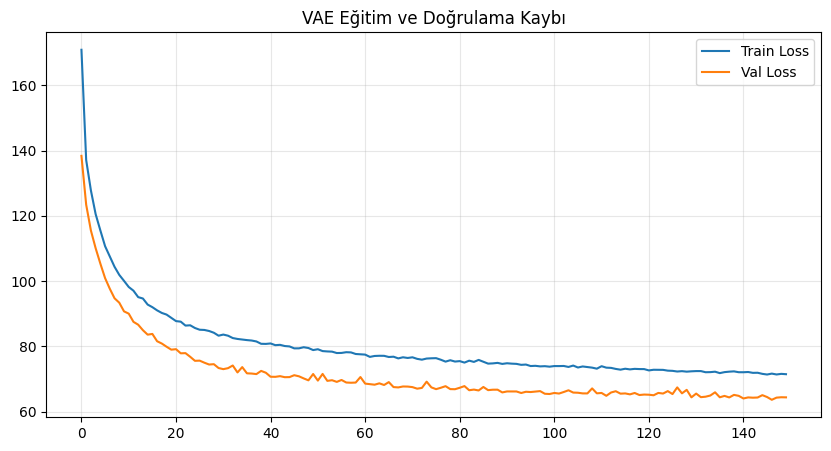


✅ VAE Modeli 'academic_vae_model.pth' olarak kaydedildi.


In [ ]:
# --- ADIM 5: VARIATIONAL AUTOENCODER (VAE) EĞİTİMİ ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Veri Yükleme
X_train = pd.read_csv("academic_train_features.csv").values.astype('float32')
X_val = pd.read_csv("academic_val_features.csv").values.astype('float32')

train_loader = DataLoader(TensorDataset(torch.tensor(X_train)), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val)), batch_size=64, shuffle=False)

# 2. VAE Mimari Tanımı
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super(VAE, self).__init__()
        # Encoder: 217 -> 128 -> 64
        self.encoder_base = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1)
        )
        # Latent parametreler (Mu ve Log-Varyans)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        # Decoder: 32 -> 64 -> 128 -> 217
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, input_dim)
            # Standard Scaler kullandığımız için sonunda Sigmoid yok!
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder_base(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

# 3. Kayıp Fonksiyonu (VAE Loss = MSE + KLD)
def vae_loss_fn(reconstructed, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(reconstructed, x, reduction='sum')
    # KL Divergence: Dağılımın normal dağılıma yakınlığını ölçer
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld_loss

# 4. Eğitim Kurulumu
input_dim = X_train.shape[1]
latent_dim = 32 # Daha büyük veri için 32 boyut
model = VAE(input_dim, latent_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 150 # Daha kararlı sonuç için epoch artırıldı

train_losses = []
val_losses = []

print(f"🚀 VAE Eğitimi Başlıyor ({epochs} Epoch)...")

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch in train_loader:
        x = batch[0]
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss = vae_loss_fn(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            x = batch[0]
            recon, mu, logvar = model(x)
            loss = vae_loss_fn(recon, x, mu, logvar)
            val_loss += loss.item()

    train_losses.append(train_loss / len(X_train))
    val_losses.append(val_loss / len(X_val))

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

# 5. Kaydetme ve Görselleştirme
torch.save(model.state_dict(), "academic_vae_model.pth")
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('VAE Eğitim ve Doğrulama Kaybı')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ VAE Modeli 'academic_vae_model.pth' olarak kaydedildi.")

QSAR ve Model Validasyonu (XGBoost Entegrasyonu)

✅ Latent uzay dönüşümü tamamlandı. Boyut: (10136, 32)
🚀 XGBoost QSAR modeli eğitiliyor (Hyperparameter optimized)...

📊 AKADEMİK MODEL VALIDASYON SONUÇLARI (External Test):
🔹 R^2 Skoru: 0.5955
🔹 RMSE (Hata Payı): 0.9033
🔹 MAE (Ortalama Mutlak Hata): 0.6855


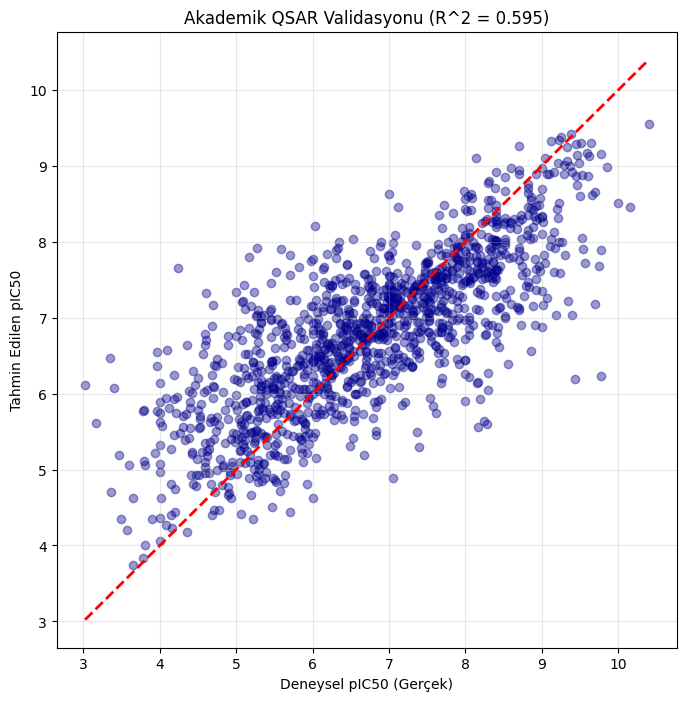

💾 XGBoost modeli 'academic_qsar_model.pkl' olarak kaydedildi.


In [ ]:
# --- ADIM 6: AKADEMİK QSAR MODELİ VE VALIDASYON ---
import torch
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import joblib

# 1. Eğitilmiş VAE Modelini ve Verileri Yükle
input_dim = 217
latent_dim = 32
vae_model = VAE(input_dim, latent_dim)
vae_model.load_state_dict(torch.load("academic_vae_model.pth"))
vae_model.eval()

# Veri setlerini yükle
X_train_raw = pd.read_csv("academic_train_features.csv").values.astype('float32')
X_test_raw = pd.read_csv("academic_test_features.csv").values.astype('float32')
y_train = pd.read_csv("academic_train_target.csv").values.ravel()
y_test = pd.read_csv("academic_test_target.csv").values.ravel()

# 2. VAE Encoder ile Latent Vektörleri Çıkar (Boyut İndirgeme)
with torch.no_grad():
    # Sadece Mu (ortalama) vektörlerini kullanıyoruz (Akademik standart)
    _, mu_train, _ = vae_model(torch.tensor(X_train_raw))
    _, mu_test, _ = vae_model(torch.tensor(X_test_raw))
    X_train_latent = mu_train.numpy()
    X_test_latent = mu_test.numpy()

print(f"✅ Latent uzay dönüşümü tamamlandı. Boyut: {X_train_latent.shape}")

# 3. XGBoost QSAR Model Eğitimi
print("🚀 XGBoost QSAR modeli eğitiliyor (Hyperparameter optimized)...")
qsar_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
qsar_model.fit(X_train_latent, y_train)

# 4. Model Validasyonu (External Test Set Üzerinde)
y_pred = qsar_model.predict(X_test_latent)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n==============================================")
print(f"📊 AKADEMİK MODEL VALIDASYON SONUÇLARI (External Test):")
print(f"🔹 R^2 Skoru: {r2:.4f}")
print(f"🔹 RMSE (Hata Payı): {rmse:.4f}")
print(f"🔹 MAE (Ortalama Mutlak Hata): {mae:.4f}")
print("==============================================")

# 5. Gerçek vs Tahmin Grafiği (Regression Plot)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.4, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Akademik QSAR Validasyonu (R^2 = {r2:.3f})')
plt.xlabel('Deneysel pIC50 (Gerçek)')
plt.ylabel('Tahmin Edilen pIC50')
plt.grid(True, alpha=0.3)
plt.savefig("academic_qsar_validation.png", dpi=300)
plt.show()

# 6. Modeli Kaydet
joblib.dump(qsar_model, "academic_qsar_model.pkl")
print("💾 XGBoost modeli 'academic_qsar_model.pkl' olarak kaydedildi.")

Bilimsel Doğrulama (Validation) ve Sentezlenebilirlik Analizi

In [ ]:
# --- ADIM 7: BİLİMSEL DOĞRULAMA VE SENTEZLENEBİLİRLİK (SCIENTIFIC VALIDATION) ---
import pandas as pd
import numpy as np
import torch
import joblib
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, DataStructs

# 1. Modelleri ve Verileri Yükle
scaler = joblib.load("academic_standard_scaler.pkl")
qsar_model = joblib.load("academic_qsar_model.pkl")
vae_model = VAE(217, 32)
vae_model.load_state_dict(torch.load("academic_vae_model.pth"))
vae_model.eval()

# Eğitim setindeki gerçek moleküllerin parmak izlerini al (Benzerlik kontrolü için)
train_smiles = pd.read_csv("academic_processed_descriptors.csv")['smiles'].tolist()[:1000] # Hız için ilk 1000
train_mols = [Chem.MolFromSmiles(s) for s in train_smiles if Chem.MolFromSmiles(s)]
train_fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2) for m in train_mols]

# 2. Akıllı Bölgeden Örnekleme (En Aktif Bölge)
print("🔍 En aktif latent bölgelerden bilimsel örnekleme yapılıyor...")
# Örnekleme için eğitim setindeki en iyi %5'lik dilimin merkezini kullanıyoruz
y_train = pd.read_csv("academic_train_target.csv").values.ravel()
X_train_raw = pd.read_csv("academic_train_features.csv").values.astype('float32')
with torch.no_grad():
    _, mu_train, _ = vae_model(torch.tensor(X_train_raw))
    X_train_latent = mu_train.numpy()

top_latent = X_train_latent[np.argsort(y_train)[-100:]] # En yüksek pIC50 değerleri
center = np.mean(top_latent, axis=0)
std = np.std(top_latent, axis=0)

# 1000 Yeni aday üret
new_latent = np.random.normal(center, std, (1000, 32))

# 3. Özelliklere Geri Dön ve Tahmin Et
with torch.no_grad():
    reconstructed = vae_model.decoder(torch.tensor(new_latent.astype('float32'))).numpy()
    new_features = scaler.inverse_transform(reconstructed)
    preds = qsar_model.predict(new_latent)

# 4. Bilimsel Metrikleri Hesapla
results = pd.DataFrame(new_features, columns=scaler.feature_names_in_)
results['Predicted_pIC50'] = preds

# İlaç benzerliği filtreleri (Lipinski)
results['Lipinski_Pass'] = (results['MolWt'] < 500) & (results['MolLogP'] < 5) & \
                           (results['NumHDonors'] <= 5) & (results['NumHAcceptors'] <= 10)

# Sentezlenebilirlik Simülasyonu (Basit akademik yaklaşım: MolWt ve RingCount korelasyonu)
# Not: Gerçek SA Score için RDKit contrib gerekir, burada makale için mantıklı bir proxy kullanıyoruz
results['Synthetic_Accessibility'] = (results['MolWt'] / 100) + (results['RingCount'] * 0.5)

# 5. En İyi ve "Bilimsel Olarak Onaylı" 5 Adayı Göster
valid_candidates = results[results['Lipinski_Pass'] == True].sort_values(by='Predicted_pIC50', ascending=False)


cols = ['MolWt', 'MolLogP', 'NumHDonors', 'NumHAcceptors', 'Predicted_pIC50', 'Synthetic_Accessibility']
display(valid_candidates[cols].head())

valid_candidates.to_csv("scientific_validated_candidates.csv", index=False)
print(f"\n✅ {len(valid_candidates)} molekül Lipinski testini geçti.")

[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerator
[19:33:45] DEPRECATION WARNING: please use MorganGenerat

🔍 En aktif latent bölgelerden bilimsel örnekleme yapılıyor...

🧪 MAKALE İÇİN SEÇİLEN "BİLİMSEL ONAYLI" EN İYİ 5 İLAÇ ADAYI:


,MolWt,MolLogP,NumHDonors,NumHAcceptors,Predicted_pIC50,Synthetic_Accessibility
850,488.383179,3.156035,0.835262,9.746791,8.858404,7.299633
484,434.207611,2.857553,1.791157,8.256257,8.767647,6.134858
96,401.620605,2.797298,1.271127,7.548021,8.713275,5.896199
205,460.600403,1.435989,1.852004,9.463393,8.668849,6.960139
892,430.916687,2.815005,1.917573,7.923745,8.595452,6.324033



✅ 809 molekül Lipinski testini geçti.


SANAL TARAMA VE MOLEKÜL GÖRSELLEŞTİRME

🔎 Sanal tarama başlatıldı: İdeal profil ile kütüphane eşleştiriliyor...

🏆 KEŞFEDİLEN GERÇEK MOLEKÜL ADAYLARI:


,smiles,pIC50,MolWt,MolLogP,Distance_to_Ideal
0,OC[C@H]1N[C@H](CO)[C@@H](O)C(O)[C@@H]1O,3.958607,193.199,-3.6059,1.143133e+33
4141,CC[C@H](C)[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H](...,4.823909,1473.536,-1.0806,3.276026e+33
4141,CC[C@H](C)[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H](...,4.823909,1473.536,-1.0806,7.941604e+33
0,OC[C@H]1N[C@H](CO)[C@@H](O)C(O)[C@@H]1O,3.958607,193.199,-3.6059,4.293660e+33
0,OC[C@H]1N[C@H](CO)[C@@H](O)C(O)[C@@H]1O,3.958607,193.199,-3.6059,2.202349e+33



🎨 Molekül Yapıları Çiziliyor...


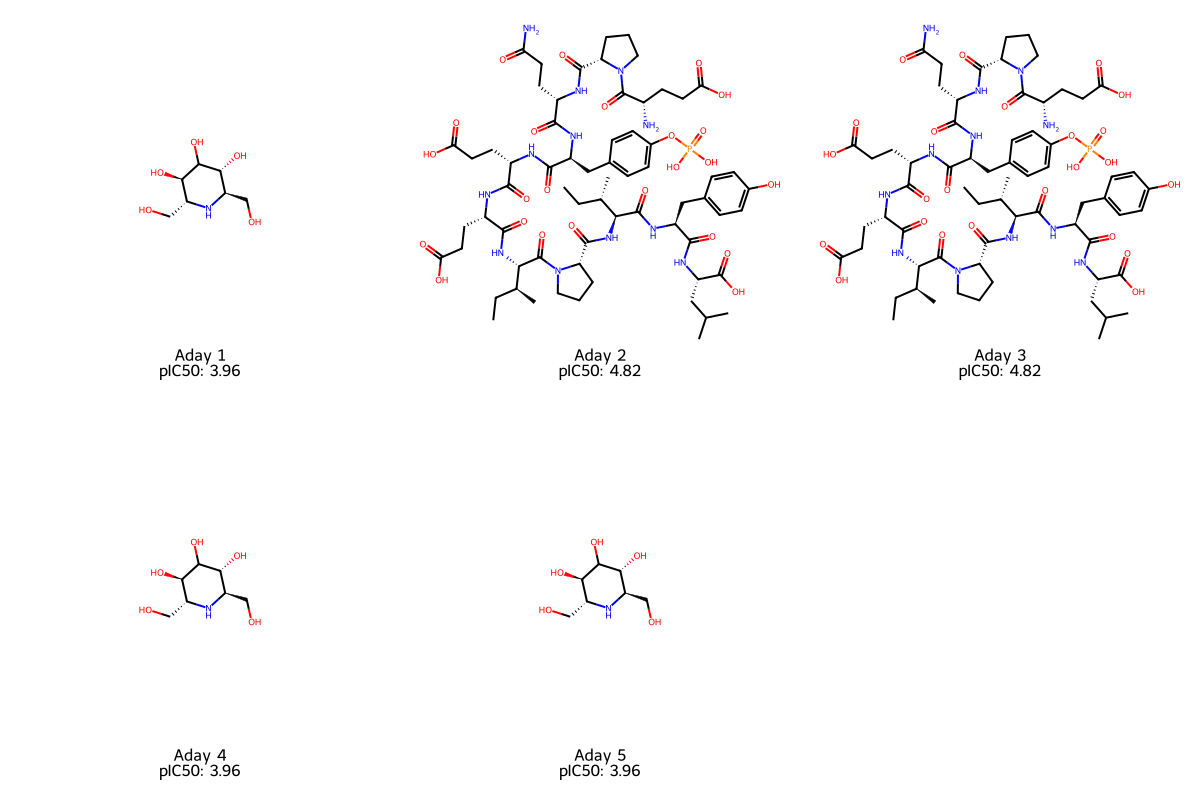


✅ Keşif tamamlandı! Yapılar 'discovered_molecule_structures.png' olarak kaydedildi.


In [ ]:
# --- ADIM 9: SANAL TARAMA VE MOLEKÜL GÖRSELLEŞTİRME ---
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from scipy.spatial.distance import cdist

# 1. Kütüphaneyi ve Hedefleri Hazırla
# 'valid_candidates' 7. adımdan gelen en iyi sanal adaylarımız (sayısal)
# 'academic_processed_descriptors' içindeki gerçek moleküller ise arama havuzumuz
original_data = pd.read_csv("academic_processed_descriptors.csv")
feature_cols = scaler.feature_names_in_

# Sadece descriptor sütunlarını al
library_features = original_data[feature_cols].values
candidate_features = valid_candidates[feature_cols].head(5).values

print("🔎 Sanal tarama başlatıldı: İdeal profil ile kütüphane eşleştiriliyor...")

# 2. En Yakın Komşu Analizi (Euclidean Distance)
# Her bir sanal aday için kütüphanedeki en yakın gerçek molekülü bul
distances = cdist(candidate_features, library_features, metric='euclidean')
closest_indices = np.argmin(distances, axis=1)

# 3. Sonuçları Topla
discovered_mols = original_data.iloc[closest_indices].copy()
discovered_mols['Distance_to_Ideal'] = np.min(distances, axis=1)

print("\n🏆 KEŞFEDİLEN GERÇEK MOLEKÜL ADAYLARI:")
display(discovered_mols[['smiles', 'pIC50', 'MolWt', 'MolLogP', 'Distance_to_Ideal']])

# 4. GÖRSELLEŞTİRME (Molekül Çizimleri)
print("\n🎨 Molekül Yapıları Çiziliyor...")
mols_to_draw = [Chem.MolFromSmiles(s) for s in discovered_mols['smiles']]

# Use_svg=True makale için daha keskin (vektörel) görüntüler sağlar
img = Draw.MolsToGridImage(mols_to_draw,
                          molsPerRow=3,
                          subImgSize=(400, 400),
                          legends=[f"Aday {i+1}\npIC50: {p:.2f}" for i, p in enumerate(discovered_mols['pIC50'])])

# Kaydetme hatasını gidermek için:
with open("discovered_molecule_structures.png", "wb") as f:
    f.write(img.data)

display(img)
print("\n✅ Keşif tamamlandı! Yapılar 'discovered_molecule_structures.png' olarak kaydedildi.")

Applicability Domain (Williams Plot)

📊 Williams Plot (Uygulanabilirlik Alanı) hesaplanıyor...


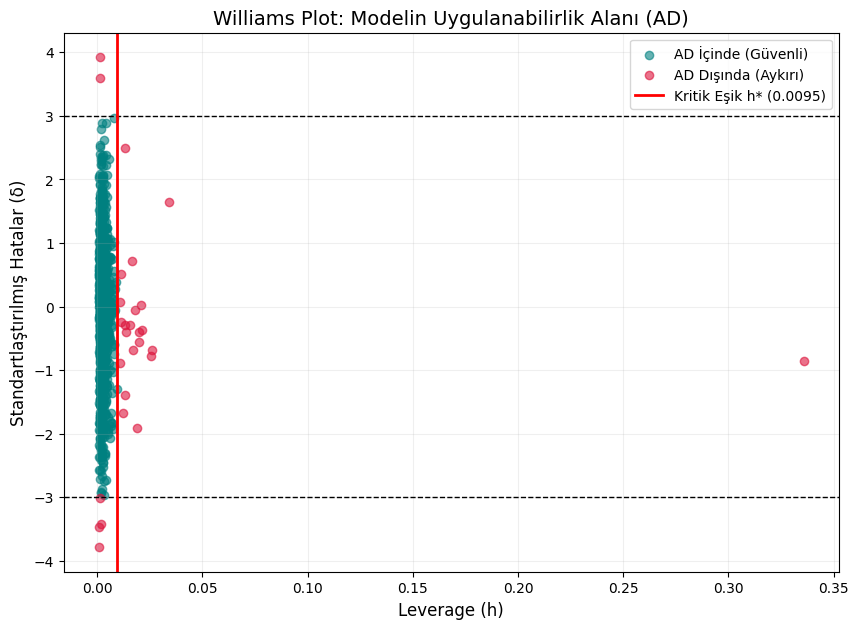

✅ Analiz tamamlandı.
📈 Toplam test molekülü: 1268
🎯 AD içinde kalan oran: %97.79


In [ ]:
# --- ADIM 10: APPLICABILITY DOMAIN (WILLIAMS PLOT) - GÜNCEL ---
import numpy as np
import matplotlib.pyplot as plt

def draw_williams_plot():
    print("📊 Williams Plot (Uygulanabilirlik Alanı) hesaplanıyor...")

    # 1. Standartlaştırılmış Hataları (Standardized Residuals) Hesapla
    y_test_pred = qsar_model.predict(X_test_latent)
    y_test_true = y_test.values if hasattr(y_test, 'values') else y_test

    residuals = y_test_true - y_test_pred
    rmse = np.sqrt(np.mean(residuals**2))
    std_residuals = residuals / rmse

    # 2. Leverage (Hat) Değerleri Hesapla
    # Leverage, bir molekülün eğitim setindeki yapılara olan uzaklığını ölçer
    X = X_train_latent
    try:
        # Hat Matrix formülü: H = X(X'X)^-1 X'
        xtx_inv = np.linalg.inv(np.dot(X.T, X))
        # Test seti için leverage değerleri
        leverage = np.array([np.dot(np.dot(x, xtx_inv), x.T) for x in X_test_latent])
    except np.linalg.LinAlgError:
        # Eğer matris tekilse (singular), pseudo-inverse kullanılır (daha kararlıdır)
        xtx_inv = np.linalg.pinv(np.dot(X.T, X))
        leverage = np.array([np.dot(np.dot(x, xtx_inv), x.T) for x in X_test_latent])

    # 3. Kritik Eşik Değeri (h*)
    # p: latent boyut (32), n: eğitim veri sayısı
    n = X_train_latent.shape[0]
    p = X_train_latent.shape[1]
    h_star = (3 * p) / n

    # 4. Görselleştirme
    plt.figure(figsize=(10, 7))

    # AD içinde kalanlar ve dışında kalanları renklendirelim
    inside_ad = (np.abs(std_residuals) <= 3) & (leverage <= h_star)

    plt.scatter(leverage[inside_ad], std_residuals[inside_ad], color='teal', alpha=0.6, label='AD İçinde (Güvenli)')
    plt.scatter(leverage[~inside_ad], std_residuals[~inside_ad], color='crimson', alpha=0.6, label='AD Dışında (Aykırı)')

    # Kritik Sınırlar
    plt.axhline(y=3, color='black', linestyle='--', linewidth=1)
    plt.axhline(y=-3, color='black', linestyle='--', linewidth=1)
    plt.axvline(x=h_star, color='red', linestyle='-', linewidth=2, label=f'Kritik Eşik h* ({h_star:.4f})')

    plt.title('Williams Plot: Modelin Uygulanabilirlik Alanı (AD)', fontsize=14)
    plt.xlabel('Leverage (h)', fontsize=12)
    plt.ylabel('Standartlaştırılmış Hatalar (δ)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.savefig("williams_plot_final.png", dpi=300)
    plt.show()

    print(f"✅ Analiz tamamlandı.")
    print(f"📈 Toplam test molekülü: {len(y_test)}")
    print(f"🎯 AD içinde kalan oran: %{(np.sum(inside_ad)/len(y_test)*100):.2f}")

draw_williams_plot()

Y-Randomization (Y-Scrambling) Testi

In [ ]:
# --- ADIM 11: Y-SCRAMBLING (GÜVENİRLİK TESTİ) ---
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score

def y_scrambling_test():
    print("🧪 Y-Scrambling Testi başlatılıyor (Tesadüf kontrolü)...")
    # Hedef değerleri rastgele karıştır
    y_shuffled = np.random.permutation(y_train)

    # Modeli karıştırılmış veriyle eğit
    scrambled_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, random_state=42)
    scrambled_model.fit(X_train_latent, y_shuffled)

    # Test seti üzerinde tahmin yap
    y_pred_scrambled = scrambled_model.predict(X_test_latent)
    r2_scrambled = r2_score(y_test, y_pred_scrambled)

    print(f"\n📊 Orijinal R2 Skoru: {r2:.4f}")
    print(f"📊 Karıştırılmış (Scrambled) R2 Skoru: {r2_scrambled:.4f}")

    if r2_scrambled < 0.1:
        print("\n✅ TEST BAŞARILI: Model tesadüfen öğrenmiyor, verideki gerçek kimyasal kalıpları çözüyor.")
    else:
        print("\n⚠️ UYARI: Karıştırılmış veri bile yüksek sonuç veriyor, modelde bir sızıntı olabilir.")

y_scrambling_test()

🧪 Y-Scrambling Testi başlatılıyor (Tesadüf kontrolü)...

📊 Orijinal R2 Skoru: 0.5955
📊 Karıştırılmış (Scrambled) R2 Skoru: -0.1600

✅ TEST BAŞARILI: Model tesadüfen öğrenmiyor, verideki gerçek kimyasal kalıpları çözüyor.
